# Experiment: SML2010 Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge,RidgeCV
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, KFold
from sklearn import preprocessing
from sklearn.model_selection import cross_val_score
from sklearn.utils import resample
import seaborn as sns

import torch
from torch.utils.data import Dataset,DataLoader
from torch import optim
import torch.nn as nn
import torch.nn.utils.prune as prune
import torch.nn.functional as F

import psutil, os

import random



In [7]:
# Read header line to get column names
import re
with open('../../data/sml2010/NEW-DATA-1.T15.txt', 'r') as f:
    header_line = f.readline().strip()

# Extract column names from header (remove # and split by whitespace)
header_line = header_line.lstrip('#').strip()
column_names = re.split(r'\s+', header_line)

# Read data files with proper separator (multiple whitespaces) and skip header line
df1=pd.read_csv('../../data/sml2010/NEW-DATA-1.T15.txt', sep=r'\s+', skiprows=1, header=None, names=column_names)
df2=pd.read_csv('../../data/sml2010/NEW-DATA-2.T15.txt', sep=r'\s+', skiprows=1, header=None, names=column_names)
tt=len(df1)
df=pd.concat([df1,df2],ignore_index=True)
df=df.drop(columns=['1:Date','2:Time','3:Temperature_Comedor_Sensor','5:Weather_Temperature','19:Exterior_Entalpic_1','20:Exterior_Entalpic_2','21:Exterior_Entalpic_turbo','24:Day_Of_Week']) 
df.head()

,4:Temperature_Habitacion_Sensor,6:CO2_Comedor_Sensor,7:CO2_Habitacion_Sensor,8:Humedad_Comedor_Sensor,9:Humedad_Habitacion_Sensor,10:Lighting_Comedor_Sensor,11:Lighting_Habitacion_Sensor,12:Precipitacion,13:Meteo_Exterior_Crepusculo,14:Meteo_Exterior_Viento,15:Meteo_Exterior_Sol_Oest,16:Meteo_Exterior_Sol_Est,17:Meteo_Exterior_Sol_Sud,18:Meteo_Exterior_Piranometro,22:Temperature_Exterior_Sensor,23:Humedad_Exterior_Sensor
0,17.8275,216.560,221.920,39.9125,42.4150,81.6650,113.520,0.0,623.360,1.42625,9690.24,12604.20,95436.8,758.880,18.1150,48.3750
1,18.1207,219.947,220.363,39.9267,42.2453,81.7413,113.605,0.0,623.211,1.59200,11022.00,10787.20,95436.8,762.069,18.4147,47.8080
2,18.4367,219.403,218.933,39.7720,42.2267,81.4240,113.600,0.0,622.656,1.89133,13960.50,9669.63,95398.6,766.251,18.8533,47.4320
3,18.7513,218.613,217.045,39.7760,42.0987,81.5013,113.344,0.0,622.571,1.82800,18511.20,9648.13,95360.3,766.037,19.2907,47.0240
4,19.0414,217.714,216.080,39.7757,42.0686,81.4657,113.034,0.0,622.400,2.36071,26349.00,9208.32,95354.9,762.743,19.7400,45.4743


In [9]:
x=df.iloc[:,1:]
y=df.iloc[:,0]
x=preprocessing.StandardScaler().fit(x).transform(x) #normalize
x=pd.DataFrame(x)
y=pd.DataFrame(y)
data=pd.concat([y,x],axis=1)

train,calibration=train_test_split(data[:tt],test_size=0.5, random_state=1)
test=data[tt:]
train_y = train.iloc[:,0]
train_x = train.iloc[:,1:]
calibration_y = calibration.iloc[:,0]
calibration_x = calibration.iloc[:,1:]
test_y = test.iloc[:,0]
test_x = test.iloc[:,1:]

train_x.reset_index(drop=True, inplace=True) 
test_x.reset_index(drop=True, inplace=True) 
train_y.reset_index(drop=True, inplace=True) 
test_y.reset_index(drop=True, inplace=True) 

train_x.shape,calibration_x.shape,test_x.shape

((1382, 15), (1382, 15), (1373, 15))

In [10]:
train_x=train_x.to_numpy()
train_y=train_y.to_numpy()
calibration_x=calibration_x.to_numpy()
calibration_y=calibration_y.to_numpy()
test_x=test_x.to_numpy()
test_y=test_y.to_numpy()

In [11]:

print("NaNs in train_x:", np.isnan(train_x).any())
print("NaNs in calibration_x:", np.isnan(calibration_x).any())
print("NaNs in test_x:", np.isnan(test_x).any())

print("NaNs per column in train_x:", np.isnan(train_x).sum(axis=0))
print("NaNs per column in test_x:", np.isnan(test_x).sum(axis=0))
print("Rows in train_x with any NaN:", np.isnan(train_x).any(axis=1).sum())
print("Rows in test_x with any NaN:", np.isnan(test_x).any(axis=1).sum())


NaNs in train_x: False
NaNs in calibration_x: False
NaNs in test_x: False
NaNs per column in train_x: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
NaNs per column in test_x: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Rows in train_x with any NaN: 0
Rows in test_x with any NaN: 0


In [12]:
nntrain_x = torch.from_numpy(train_x).float()
nntrain_y = torch.squeeze(torch.from_numpy(train_y).float()) 
nntest_x= torch.from_numpy(test_x).float()
nntest_y = torch.squeeze(torch.from_numpy(test_y).float())

class mydataset(Dataset):
    def __init__(self, x, y):
        self._x = x
        self._y = y
        self._len = len(x)

    def __getitem__(self, item): 
        return self._x[item], self._y[item]

    def __len__(self):
        return self._len

In [13]:
GLOBAL_SEED = 7199   # or any integer you choose

def set_global_seed(seed: int):
    if seed is None:
        seed = GLOBAL_SEED
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
def measure_time(func, *args, **kwargs):
    """
    Measure wall-clock time of func(*args, **kwargs).
    Returns (result, runtime_in_seconds).
    """
    t0 = time.time()
    result = func(*args, **kwargs)
    t1 = time.time()
    return result, (t1 - t0)


def measure_memory_cpu(func, *args, **kwargs):
    process = psutil.Process(os.getpid())
    mem_before = process.memory_info().rss  # bytes

    result = func(*args, **kwargs)

    mem_after = process.memory_info().rss
    delta_mb = (mem_after - mem_before) / 1024**2
    after_mb = mem_after / 1024**2

    return result, delta_mb, after_mb


def measure_memory_gpu(func, *args, **kwargs):
    """
    Measure peak GPU memory allocated during func().
    Returns: (result, peak_MB or None)
    """
    if not torch.cuda.is_available():
        return func(*args, **kwargs), None

    torch.cuda.reset_peak_memory_stats()

    result = func(*args, **kwargs)

    peak_bytes = torch.cuda.max_memory_allocated()
    peak_mb = peak_bytes / 1024**2

    return result, peak_mb


### Random Feature

In [14]:
def sample_1d(pdf, gamma):
    if pdf=='G':
        w=torch.randn(1)*gamma
        return w
    elif pdf=='L':
        w=torch.distributions.laplace.Laplace(torch.tensor([0.0]), torch.tensor([1.0])).sample()*gamma
        return w
    elif pdf=='C':
        w=torch.distributions.cauchy.Cauchy(torch.tensor([0.0]), torch.tensor([1.0])).sample()*gamma
        return w
    
def sample(pdf, gamma, d):
    return torch.tensor([sample_1d(pdf, gamma) for _ in range(d)])

class RandomFourierFeature:
    """Random Fourier Feature
    Parameters
    ----------
    d : int
        Input space dimension
    D : int
        Feature space dimension
    W : shape (D,d)
    b : shape (D)
    kernel : char
        Kernel to use; 'G', 'L', or 'C'
    gamma : float
        pdf parameter
    """

    def __init__(self, d, D, W=None, b=None, kernel='G', gamma=1):

        self.d = d
        self.D = D
        self.gamma = gamma

        kernel = kernel.upper()
        if kernel not in ['G', 'L', 'C']:
            raise Exception('Invalid Kernel')
        self.kernel = kernel

        if W is None or b is None:
            self.create()
        else:
            self.__load(W, b)

    def __load(self, W, b):
        """Load from existing Arrays"""

        self.W = W.reshape([self.D, self.d])
        self.b = b
    

    def create(self):
        """Create a d->D fourier random feature"""

        self.b = torch.rand(self.D)*2*torch.pi
        self.W = sample(self.kernel, self.gamma, self.d*self.D).reshape(self.D,self.d)

    def transform(self, x):
        """Transform a vector using this feature
        Parameters
        ----------
        x : (shape=(n,d))
            to transform; must be single dimension vector
        Returns
        -------
        x : (shape=(n,D))
            Feature space transformation of x
        """
        #print(self.W.shape,self.b.reshape(-1,1).shape,x.shape)
        #print((self.W @ x.T).shape)
       
        result=torch.sqrt(torch.tensor([2.0/self.D])) * torch.cos( self.W @ x.T  + (self.b.reshape(-1,1) @ torch.ones(len(x)).reshape(1,-1))) 
        #print(result.T.shape)
        return result.T

In [15]:
def run_rf_ridge(train_x, train_y, test_x, test_y,
                 calibration_x, calibration_y,
                 D=500, gamma=0.4, seed=7199):
    """
    Train RF + Ridge and return (train_mse, test_mse).
    No timing or memory in here.
    """
    set_global_seed(seed)
    rff = RandomFourierFeature(d=train_x.shape[1], D=D,
                               kernel='G', gamma=gamma)

    total_x = np.vstack((train_x, calibration_x))
    total_y = np.hstack((train_y, calibration_y))

    # Random Fourier Features
    total_feature = rff.transform(total_x)
    test_feature  = rff.transform(test_x)

    # Ridge + CV
    model = Ridge()
    param_grid = {'alpha': [1e-4,1e-3,1e-2,1e-1,1]}
    kf = KFold(n_splits=5, shuffle=True)

    grid_search = GridSearchCV(model, param_grid, cv=kf)
    grid_search.fit(total_feature, total_y)

    best_model = grid_search.best_estimator_
    rf_pred_total = best_model.predict(total_feature)
    rf_pred_test  = best_model.predict(test_feature)

    train_mse = mean_squared_error(total_y, rf_pred_total)
    test_mse  = mean_squared_error(test_y, rf_pred_test)
    return train_mse, test_mse


def rf_core():
    return run_rf_ridge(train_x, train_y, test_x, test_y,
                        calibration_x, calibration_y,
                        D=500, gamma=0.4, seed=7199)


(rf_result, rf_delta_cpu_mb, rf_cpu_after_mb), rf_time = measure_time(
    lambda: measure_memory_cpu(rf_core)
)

rf_train_mse, rf_test_mse = rf_result

print("RF train MSE:", rf_train_mse)
print("RF test MSE:",  rf_test_mse)
print("RF runtime (s):", rf_time)
print("RF CPU Δ memory (MB):", rf_delta_cpu_mb)
print("RF CPU final RSS (MB):", rf_cpu_after_mb)


/var/folders/z7/p968ccvd4d9c27v5n0y0qbyw0000gn/T/ipykernel_35466/462636501.py:74: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  result=torch.sqrt(torch.tensor([2.0/self.D])) * torch.cos( self.W @ x.T  + (self.b.reshape(-1,1) @ torch.ones(len(x)).reshape(1,-1)))


RF train MSE: 0.12030349259008852
RF test MSE: 3.272971797052998
RF runtime (s): 0.44725608825683594
RF CPU Δ memory (MB): 81.09375
RF CPU final RSS (MB): 209.8125


## 1. DNN

In [16]:
class Net(nn.Module):
    def __init__(self):
        super(Net,self).__init__()
        self.fc1 = nn.Linear(15, 100)
        self.fc2 = nn.Linear(100, 50)
        self.fc3 = nn.Linear(50, 1)
    def forward(self,x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)




In [17]:
#initialize
def init_weights(m):
    if type(m) == nn.Conv2d:
        torch.nn.init.normal_(m.weight,mean=0,std=0.5)
    if type(m) == nn.Linear:
        torch.nn.init.uniform_(m.weight,a=0,b=0.1)
        m.bias.data.fill_(0)

def run_dnn(train_x, train_y, test_x, test_y,
            batch_size=256,
            max_epochs=1000,
            early_stop_window=50,
            lr=1e-4,
            momentum=0.9,
            weight_decay=1e-2,
            device=None,
            verbose=False,
            seed=7199):
    """
    Train the DNN and return (train_mse, test_mse, num_epochs_run).
    No timing or memory measurement inside.
    """

    # reproducibility
    set_global_seed(seed)

    # choose device
    if device is None:
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # numpy -> tensors
    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    nntest_x  = torch.from_numpy(test_x).float()
    nntest_y  = torch.from_numpy(test_y).float().squeeze()

    train_loader = DataLoader(mydataset(nntrain_x, nntrain_y),
                              batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(mydataset(nntest_x, nntest_y),
                              batch_size=batch_size, shuffle=False)

    # model, loss, optimizer
    net = Net().to(device)
    net.apply(init_weights)

    criterion = nn.MSELoss()
    optimizer = optim.SGD(net.parameters(),
                          lr=lr,
                          momentum=momentum,
                          weight_decay=weight_decay)

    dnn_trainloss = []
    dnn_testloss  = []

    for epoch in range(max_epochs):
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            y_pred = net(x).squeeze()
            train_loss = criterion(y_pred, y)
            train_loss.backward()
            optimizer.step()

        # evaluate full train & test MSE (like your original code)
        net.eval()
        with torch.no_grad():
            # train MSE
            x0 = torch.from_numpy(train_x).float().to(device)
            pred_train = net(x0).squeeze().cpu().numpy()
            train_mse = mean_squared_error(train_y, pred_train)
            dnn_trainloss.append(train_mse)

            # test MSE
            x1 = torch.from_numpy(test_x).float().to(device)
            pred_test = net(x1).squeeze().cpu().numpy()
            test_mse = mean_squared_error(test_y, pred_test)
            dnn_testloss.append(test_mse)

        # early stopping: same idea as your code
        if epoch > early_stop_window:
            if float(dnn_trainloss[-1]) > max(dnn_trainloss[-early_stop_window:-1]):
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

        if verbose and epoch % 50 == 0:
            print(f"epoch {epoch:4d}  train MSE: {dnn_trainloss[-1]:.6f}  "
                  f"test MSE: {dnn_testloss[-1]:.6f}")

    num_epochs_run = len(dnn_trainloss)
    final_train_mse = dnn_trainloss[-1]
    final_test_mse  = dnn_testloss[-1]

    return final_train_mse, final_test_mse, num_epochs_run


In [2]:
def dnn_core():
    return run_dnn(train_x, train_y, test_x, test_y)

# GPU wrapper inside, CPU wrapper around it, then time
((dnn_result, dnn_peak_gpu_mb), dnn_delta_cpu_mb, dnn_cpu_after_mb), dnn_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(dnn_core)
    )
)


dnn_train_mse, dnn_test_mse, dnn_epochs = dnn_result

print("DNN train MSE:", dnn_train_mse)
print("DNN test MSE:",  dnn_test_mse)
print("DNN time:", dnn_time)
print("DNN peak GPU (MB):", dnn_peak_gpu_mb)
print("DNN CPU Δ (MB):", dnn_delta_cpu_mb)
print("DNN CPU final (MB):", dnn_cpu_after_mb)


NameError: name 'measure_time' is not defined

## 2. Resnet

In [19]:
class ResidualBlock(nn.Module):
    def __init__(self,infeatures,outfeatures):
        super(ResidualBlock,self).__init__()
        self.infeatures = infeatures
        self.outfeatures = outfeatures
        self.fc1 = nn.Linear(infeatures,outfeatures)
        self.fc2 = nn.Linear(infeatures,outfeatures)
    
    def forward(self, x):
        y = self.fc1(x)
        y= F.relu(y)
        x = self.fc2(x)
        return F.relu(x+y)


class ResNet(nn.Module): 
    def __init__(self):
        super(ResNet, self).__init__()
        self.rblock1 = ResidualBlock(15,100)
        self.rblock2 = ResidualBlock(100,50)
        self.fc3 = nn.Linear(50,1)
    
 
    def forward(self, x):
        x = self.rblock1(x)
        x = self.rblock2(x)
        return self.fc3(x)

#initialize
def init_weights(m):
    if type(m) == nn.Conv2d:
        torch.nn.init.normal_(m.weight,mean=0,std=0.5)
    if type(m) == nn.Linear:
        torch.nn.init.uniform_(m.weight,a=-0.1,b=0.1)
        m.bias.data.fill_(0)

In [20]:
def run_resnet(train_x, train_y, test_x, test_y,
               batch_size=256,
               max_epochs=1000,
               early_stop_window=50,
               lr=1e-4,
               momentum=0.9,
               weight_decay=1e-2,
               device=None,
               verbose=False,
               seed=7199):
    """
    Train a ResNet on tabular input and return:
        (train_mse, test_mse, num_epochs_run)
    No timing or memory measurements inside.
    """

    # ========================
    # 1. Reproducibility
    # ========================
    set_global_seed(seed)

    # Determine device
    if device is None:
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # ========================
    # 2. Convert NumPy → Tensors
    # ========================
    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    nntest_x  = torch.from_numpy(test_x).float()
    nntest_y  = torch.from_numpy(test_y).float().squeeze()

    train_loader = DataLoader(
        mydataset(nntrain_x, nntrain_y),
        batch_size=batch_size, shuffle=True
    )

    test_loader = DataLoader(
        mydataset(nntest_x, nntest_y),
        batch_size=batch_size, shuffle=False
    )

    # ========================
    # 3. Model, Loss, Optimizer
    # ========================
    net = ResNet().to(device)
    net.apply(init_weights)      # keep your initialization

    criterion = nn.MSELoss()

    optimizer = optim.SGD(
        net.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay
    )

    # ========================
    # 4. Training Loop
    # ========================
    res_trainloss = []
    res_testloss  = []
    for epoch in range(max_epochs):

        # ---- Training ----
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            y_pred = net(x).squeeze()
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()

        # ---- Evaluation ----
        net.eval()
        with torch.no_grad():
            # full train MSE
            x0 = torch.from_numpy(train_x).float().to(device)
            pred_train = net(x0).squeeze().cpu().numpy()
            train_mse = mean_squared_error(train_y, pred_train)
            res_trainloss.append(train_mse)

            # full test MSE
            x1 = torch.from_numpy(test_x).float().to(device)
            pred_test = net(x1).squeeze().cpu().numpy()
            test_mse = mean_squared_error(test_y, pred_test)
            res_testloss.append(test_mse)

        # ---- Early Skipping ----
        if epoch > early_stop_window:
            if res_trainloss[-1] > max(res_trainloss[-early_stop_window:-1]):
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

        # ---- Optional Printing ----
        if verbose and epoch % 50 == 0:
            print(f"""epoch {epoch}
                Train MSE: {train_mse}
                Test  MSE: {test_mse}
            """)

    # final metrics
    num_epochs_run = len(res_trainloss)
    final_train_mse = res_trainloss[-1]
    final_test_mse  = res_testloss[-1]
    return final_train_mse, final_test_mse, num_epochs_run


In [21]:
def resnet_core():
    return run_resnet(train_x, train_y, test_x, test_y)

((res_result, res_peak_gpu), res_delta_cpu, res_cpu_after), res_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(resnet_core)
    )
)

res_train_mse, res_test_mse, res_epochs = res_result

print("ResNet Train MSE:", res_train_mse)
print("ResNet Test  MSE:", res_test_mse)
print("ResNet Epochs:", res_epochs)
print("ResNet Time:", res_time)
print("ResNet CPU ΔMB:", res_delta_cpu)
print("ResNet GPU peak MB:", res_peak_gpu)



ResNet Train MSE: 0.23242487596133607
ResNet Test  MSE: 1.8260299673736657
ResNet Epochs: 1000
ResNet Time: 13.59834599494934
ResNet CPU ΔMB: -55.984375
ResNet GPU peak MB: None


## 2.5 DKL (NN feature extractor + GP)


In [ ]:
import gpytorch
import torch
import time
from sklearn.metrics import mean_squared_error

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 1) feature extractor
class DKLFeatureExtractor(torch.nn.Module):
    def __init__(self, in_dim=15):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(in_dim, 100),
            torch.nn.ReLU(),
            torch.nn.Linear(100, 50),
            torch.nn.ReLU(),
            #We set the embedding dimension to 2 following standard practice in deep kernel learning, 
            # and found the results to be insensitive for dimensions between 2 and 10.
            torch.nn.Linear(50, 2),   # embedding dim 可以调：2/5/10 都行
        )
    def forward(self, x):
        return self.net(x)

# 2) DKL model = ExactGP + feature extractor
class DKLExactGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, feature_extractor):
        super().__init__(train_x, train_y, likelihood)
        self.feature_extractor = feature_extractor
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
        
    def forward(self, x):
        z = self.feature_extractor(x)
        mean_x = self.mean_module(z)
        covar_x = self.covar_module(z)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# data
train_x_t = nntrain_x.to(device)
train_y_t = nntrain_y.to(device)
test_x_t  = nntest_x.to(device)
test_y_t  = nntest_y.to(device)

# init
dkl_likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
feat = DKLFeatureExtractor(in_dim=train_x_t.shape[1]).to(device)
dkl_model = DKLExactGP(train_x_t, train_y_t, dkl_likelihood, feat).to(device)

# train
training_iter = 300  # 先用 200~500
dkl_model.train()
dkl_likelihood.train()

optimizer = torch.optim.Adam([
    {'params': dkl_model.feature_extractor.parameters(), 'lr': 1e-3},
    {'params': dkl_model.covar_module.parameters()},
    {'params': dkl_model.mean_module.parameters()},
    {'params': dkl_likelihood.parameters()},
], lr=0.05)

mll = gpytorch.mlls.ExactMarginalLogLikelihood(dkl_likelihood, dkl_model)

t0 = time.time()
for i in range(training_iter):
    optimizer.zero_grad()
    output = dkl_model(train_x_t)
    loss = -mll(output, train_y_t)
    loss.backward()
    optimizer.step()
dkl_time = time.time() - t0

# eval
dkl_model.eval()
dkl_likelihood.eval()
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    pred_train = dkl_likelihood(dkl_model(train_x_t)).mean
    pred_test  = dkl_likelihood(dkl_model(test_x_t)).mean

dkl_train_mse = mean_squared_error(train_y, pred_train.detach().cpu().numpy())
dkl_test_mse  = mean_squared_error(test_y,  pred_test.detach().cpu().numpy())

print("DKL Train MSE:", dkl_train_mse)
print("DKL Test  MSE:", dkl_test_mse)
print("DKL Time (s):", dkl_time)


DKL Train MSE: 0.0811225078526719
DKL Test  MSE: 2.0941523756881404
DKL Time (s): 8.600916862487793


/Users/wanghd/Desktop/Research/Dai/Multi_layer_kernel_machines/Multi-Layer-Kernel-Machine/venv/lib/python3.13/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


## 2.6 DGP baseline（Deep Gaussian Process）

In [26]:

import gpytorch
import torch
import time
from sklearn.metrics import mean_squared_error

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ----- DGP building blocks -----
class DGPLayer(gpytorch.models.deep_gps.DeepGPLayer):
    def __init__(self, input_dims, output_dims, inducing_points):
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(0)
        )
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True
        )
        super().__init__(variational_strategy, input_dims, output_dims)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

class TwoLayerDGP(gpytorch.models.deep_gps.DeepGP):
    def __init__(self, train_x_shape, num_inducing=128, hidden_dim=5):
        super().__init__()
        inducing_1 = nntrain_x[torch.randperm(nntrain_x.size(0))[:num_inducing]].to(device)
        inducing_2 = torch.randn(num_inducing, hidden_dim).to(device)

        self.hidden_layer = DGPLayer(
            input_dims=train_x_shape[1],
            output_dims=hidden_dim,
            inducing_points=inducing_1
        )
        self.output_layer = DGPLayer(
            input_dims=hidden_dim,
            output_dims=None,  # None for final layer in regression (scalar output)
            inducing_points=inducing_2
        )
        self.likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)

    def forward(self, inputs):
        hidden_rep = self.hidden_layer(inputs)
        output = self.output_layer(hidden_rep)
        return output

    def predict(self, x):
        self.eval()
        self.likelihood.eval()
        with torch.no_grad(), gpytorch.settings.num_likelihood_samples(16):
            preds = self.likelihood(self(x))
            # Average over the sample dimension (dim 0) to get [batch_size] output
            return preds.mean.mean(dim=0)

# ----- train DGP -----
train_x_t = nntrain_x.to(device)
train_y_t = nntrain_y.to(device)
test_x_t  = nntest_x.to(device)

dgp_model = TwoLayerDGP(train_x_t.shape, num_inducing=128, hidden_dim=5).to(device)

dgp_model.train()
dgp_model.likelihood.train()

optimizer = torch.optim.Adam(dgp_model.parameters(), lr=0.01)
elbo = gpytorch.mlls.DeepApproximateMLL(
    gpytorch.mlls.VariationalELBO(dgp_model.likelihood, dgp_model, num_data=train_x_t.size(0))
)

training_iter = 1000  
batch_size = 256

t0 = time.time()
for i in range(training_iter):
    perm = torch.randperm(train_x_t.size(0), device=device)
    for j in range(0, train_x_t.size(0), batch_size):
        idx = perm[j:j+batch_size]
        optimizer.zero_grad()
        output = dgp_model(train_x_t[idx])
        loss = -elbo(output, train_y_t[idx])
        loss.backward()
        optimizer.step()
dgp_time = time.time() - t0

# eval
pred_train = dgp_model.predict(train_x_t).detach().cpu().numpy()
pred_test  = dgp_model.predict(test_x_t).detach().cpu().numpy()

dgp_train_mse = mean_squared_error(train_y, pred_train)
dgp_test_mse  = mean_squared_error(test_y,  pred_test)

print("DGP Train MSE:", dgp_train_mse)
print("DGP Test  MSE:", dgp_test_mse)
print("DGP Time (s):", dgp_time)


DGP Train MSE: 0.188336288815695
DGP Test  MSE: 2.4149350779706595
DGP Time (s): 171.67178106307983


In [24]:
print("train_x_t[idx] shape:", train_x_t[idx].shape)
print("train_y_t[idx] shape:", train_y_t[idx].shape)
print("Model output shape:", dgp_model(train_x_t[idx]).mean.shape)

train_x_t[idx] shape: torch.Size([256, 15])
train_y_t[idx] shape: torch.Size([256])
Model output shape: torch.Size([10, 256, 1])


## 3. MLKM

In [ ]:
class KernelNet(nn.Module): 
    def __init__(self):
        super(KernelNet, self).__init__()
        self.fc1 = nn.Linear(100, 50)
        self.fc2 = nn.Linear(50, 1)
        
    def forward(self, x):
        x = rff1.transform(x)
        x=self.fc1(x)
        x = rff2.transform(x)
        return self.fc2(x)


#initialize
def init_weights(m):
    if type(m) == nn.Conv2d:
        torch.nn.init.normal_(m.weight,mean=0,std=0.5)
    if type(m) == nn.Linear:
        torch.nn.init.uniform_(m.weight,a=-0.1,b=0.1)
        m.bias.data.fill_(0)


def run_mlkm(train_x, train_y, test_x, test_y,
             batch_size=256,
             max_epochs=1000,
             early_stop_window=50,
             lr=7e-4,
             momentum=0.95,
             weight_decay=1e-3,
             device=None,
             verbose=False,
             seed=7199):
    """
    Train KernelNet (MLKM) and return:
        (train_mse, test_mse, num_epochs_run)

    No timing or memory measurement inside.
    """

    # -----------------------
    # 1. Reproducibility
    # -----------------------
    set_global_seed(seed)

    # Device
    if device is None:
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # -----------------------
    # 2. NumPy -> Tensors
    # -----------------------
    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    nntest_x  = torch.from_numpy(test_x).float()
    nntest_y  = torch.from_numpy(test_y).float().squeeze()

    train_loader = DataLoader(
        mydataset(nntrain_x, nntrain_y),
        batch_size=batch_size, shuffle=True
    )
    test_loader = DataLoader(
        mydataset(nntest_x, nntest_y),
        batch_size=batch_size, shuffle=False
    )

    # -----------------------
    # 3. Random Fourier Features (as in your original code)
    # -----------------------
    # If KernelNet uses these globals internally, we recreate them here
    rff1 = RandomFourierFeature(15, 100, kernel='G', gamma=0.1)
    rff2 = RandomFourierFeature(50, 50, kernel='G', gamma=0.4)
    # NOTE: if KernelNet expects rff1/rff2 as arguments, adjust its __init__ accordingly

    # -----------------------
    # 4. Model, Loss, Optimizer
    # -----------------------
    net = KernelNet().to(device)

    # match your original code: reseed before init_weights
    torch.manual_seed(1)
    net.apply(init_weights)

    criterion = nn.MSELoss()
    optimizer = optim.SGD(
        net.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay
    )

    # -----------------------
    # 5. Training Loop
    # -----------------------
    kernelnn_trainloss = []
    kernelnn_testloss  = []

    for epoch in range(max_epochs):
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            y_pred = net(x).squeeze()
            train_loss = criterion(y_pred, y)
            train_loss.backward()
            optimizer.step()

        # ---- Evaluation (train + test MSE) ----
        net.eval()
        with torch.no_grad():
            # train MSE
            x0 = torch.from_numpy(train_x).float().to(device)
            pred_train = net(x0).squeeze().cpu().numpy()
            train_mse = mean_squared_error(train_y, pred_train)
            kernelnn_trainloss.append(train_mse)

            # test MSE
            x1 = torch.from_numpy(test_x).float().to(device)
            pred_test = net(x1).squeeze().cpu().numpy()
            test_mse = mean_squared_error(test_y, pred_test)
            kernelnn_testloss.append(test_mse)

        # ---- Early stopping (same as your original) ----
        if epoch > early_stop_window:
            if kernelnn_trainloss[-1] > max(kernelnn_trainloss[-early_stop_window:-1]):
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

        # if verbose and epoch % 50 == 0:
        #     print(f"""epoch {epoch}
        #         Train MSE: {kernelnn_trainloss[-1]}
        #         Test  MSE: {kernelnn_testloss[-1]}
        #     """)

    num_epochs_run = len(kernelnn_trainloss)
    final_train_mse = kernelnn_trainloss[-1]
    final_test_mse  = kernelnn_testloss[-1]

    return final_train_mse, final_test_mse, num_epochs_run


In [53]:
def mlkm_core():
    return run_mlkm(train_x, train_y, test_x, test_y)

((mlkm_result, mlkm_peak_gpu), mlkm_delta_cpu, mlkm_cpu_after), mlkm_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(mlkm_core)
    )
)

mlkm_train_mse, mlkm_test_mse, mlkm_epochs = mlkm_result


In [54]:
print("MLKM train MSE:", mlkm_train_mse)
print("MLKM test  MSE:", mlkm_test_mse)
print("MLKM epochs run:", mlkm_epochs)
print("MLKM time:", mlkm_time)
print("MLKM CPU ΔMB:", mlkm_delta_cpu)
print("MLKM GPU peak MB:", mlkm_peak_gpu)


MLKM train MSE: 0.3590066107513897
MLKM test  MSE: 1.8385156703646224
MLKM epochs run: 1000
MLKM time: 10.07281494140625
MLKM CPU ΔMB: 0.15625
MLKM GPU peak MB: None


In [71]:
##conformal prediction
#predict

coverage=0
par=optimizer.param_groups[0]['params']
for i in tqdm(range(len(train_x))):
    x0=torch.from_numpy(train_x[i:1+i]).float()
    x0 = x0.to(device)
    pred = net(x0)
    fi=torch.tensor([])
    for j in range(len(par)):
        par[j].grad.data.zero_()
    pred.backward()   
    for j in range(len(par)): 
        fi=torch.cat([fi,par[j].grad.reshape(-1)])
    fi=fi.reshape(1,-1)
    if i==0:
        Fi=fi
    else:
        Fi=torch.cat([Fi,fi])   
temp=torch.linalg.inv(Fi.T @ Fi)

mark=0
score=torch.tensor([])
for i in tqdm(range(len(calibration_x))):
    x0=torch.from_numpy(calibration_x[i:i+1]).float()
    x0 = x0.to(device)
    pred = net(x0)
    par=optimizer.param_groups[0]['params']
    f0=torch.tensor([])
    for j in range(len(par)):
        par[j].grad.data.zero_()
    pred.backward()
    for j in range(len(par)):
        f0=torch.cat([f0,par[j].grad.reshape(-1)])
    f0=f0.reshape(-1,1)
    fFFf=f0.T @ temp @ f0
    if fFFf < 0:
        continue
    score=torch.cat([score,np.abs(pred.detach().numpy()[0][0]-calibration_y[i])/(np.sqrt(kernelnn_trainloss[-1])*np.sqrt(fFFf+1))])
    mark=mark+1
score=score.reshape(-1)
sorted_score, sorted_indices=torch.sort(score)
q=(len(score)+1)*0.95
a=sorted_score[int(np.ceil(q))]

pred_xall=[]
pred_yall=[]
true_yall=[]
dist=[]
mark=0
length=[]
for i in tqdm(range(len(test_x))):
    x0=torch.from_numpy(test_x[i:i+1]).float()
    x0 = x0.to(device)
    pred = net(x0)
    par=optimizer.param_groups[0]['params']
    f0=torch.tensor([])
    for j in range(len(par)):
        par[j].grad.data.zero_()
    pred.backward()
    for j in range(len(par)):
        f0=torch.cat([f0,par[j].grad.reshape(-1)])
    f0=f0.reshape(-1,1)

    fFFf=f0.T @ temp @ f0
    
    if fFFf < 0:
        continue
    mark=mark+1
    dd=(np.sqrt(kernelnn_trainloss[-1])*np.sqrt(fFFf+1)*a).detach().numpy()[0][0]
    length.append(2*dd)
    
    #coverage
    if pred.detach().numpy()[0][0]-dd<test_y[i] and pred.detach().numpy()[0][0]+dd>test_y[i]:
        coverage=coverage+1
    pred_xall.append(test_x[i][0])
    pred_yall.append(pred.detach().numpy()[0][0])
    true_yall.append(test_y[i])
    dist.append(dd)
coverage=coverage/mark


print("length",np.mean(length))
print("95 coverage",coverage)

 11%|█         | 148/1382 [00:00<00:00, 1473.78it/s]

torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 1

 21%|██▏       | 296/1382 [00:00<00:01, 600.55it/s] 

torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 5

 28%|██▊       | 382/1382 [00:00<00:01, 518.89it/s]

...

torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])


 99%|█████████▉| 1364/1373 [00:14<00:00, 115.15it/s]

torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])


100%|██████████| 1373/1373 [00:14<00:00, 95.19it/s] 

torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
length 6.7055445
95 coverage 0.8585858585858586


## 4. Residual multilayer learning

In [1]:
%%capture
train_loader = DataLoader(mydataset(nntrain_x, nntrain_y),batch_size=128, shuffle=True)
test_loader = DataLoader(mydataset(nntest_x, nntest_y),batch_size=128, shuffle=False)

rff0=RandomFourierFeature(15,100,kernel='G',gamma=0.1)
rff1=RandomFourierFeature(50,50,kernel='G',gamma=0.4)

class ResidualBlock(nn.Module):
    def __init__(self,infeatures,outfeatures,rff):
        super(ResidualBlock,self).__init__()
        self.infeatures = infeatures
        self.outfeatures = outfeatures
        self.rff=rff
        
        self.fc1 = nn.Linear(infeatures,outfeatures)
        self.fc2 = nn.Linear(outfeatures,outfeatures)
    
    def forward(self, x):
        rff=self.rff
        x = self.fc1(x)
        y = rff.transform(x)
        y = self.fc2(y)
        return x+y

class ResKernelNet(nn.Module): 
    def __init__(self):
        super(ResKernelNet, self).__init__()
        self.rblock1 = ResidualBlock(100,50,rff1)
        self.fc2 =nn.Linear(50,1)
 
    def forward(self, x):
        x = rff0.transform(x)
        x = self.rblock1(x)
        return self.fc2(x)

#initialize
def init_weights(m):
    if type(m) == nn.Conv2d:
        torch.nn.init.normal_(m.weight,mean=0,std=0.5)
    if type(m) == nn.Linear:
        torch.nn.init.uniform_(m.weight,a=-0.1,b=0.1)
        m.bias.data.fill_(0)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
net = ResKernelNet()
net = net.to(device)
torch.manual_seed(1)
#net.apply(init_weights)
print(net)
criterion=nn.MSELoss() 
optimizer=optim.SGD(net.parameters(),lr=1e-4,momentum=0.9,weight_decay=1e-2) #optim.Adam(...)
#optimizer=optim.SGD([{'params': net.parameters(), 'initial_lr': 1e-4}],lr=1e-4,momentum=0.9,weight_decay=1e-2) #optim.Adam(...)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer,step_size=100,gamma=0.5,last_epoch=200) 


loss=[]
reskernel_trainloss=[]
reskernel_testloss=[]
t0 = time.time()
for epoch in range(1000): 
    for x, y in train_loader: #for batch, (x, y) in enumerate(train_loader): 
        x, y = x.to(device), y.to(device)
        # Compute prediction error
        y_pred = net(x)
        y_pred = torch.squeeze(y_pred)
        train_loss = criterion(y_pred, y)
        loss.append(train_loss)
        # Backpropagation
        optimizer.zero_grad() 
        train_loss.backward()
        optimizer.step()
    #scheduler.step()
    
    x0=torch.from_numpy(train_x[:]).float()
    with torch.no_grad():
        x0 = x0.to(device)
        pred = net(x0)
    reskernel_trainloss.append(mean_squared_error(pred,train_y))
    
    x1=torch.from_numpy(test_x[:]).float()
    with torch.no_grad():
        x1 = x1.to(device)
        pred = net(x1)
    reskernel_testloss.append(mean_squared_error(pred,test_y))
    
    if epoch>50 and float(reskernel_trainloss[-1])>max(reskernel_trainloss[-50:-1]):
        break
    
    if epoch % 50 == 0:        
        print(f'''epoch {epoch}
            Train set - loss: {reskernel_trainloss[-1]}
            Test  set - loss: {reskernel_testloss[-1]}
            ''')
        
    
dnn_fit = time.time() - t0
print("Residual KernelNet complexity and model fitted in %.3f s" % dnn_fit)

NameError: name 'DataLoader' is not defined

In [73]:
##conformal prediction
#predict

coverage=0
par=optimizer.param_groups[0]['params']
for i in tqdm(range(len(train_x))):
    x0=torch.from_numpy(train_x[i:1+i]).float()
    x0 = x0.to(device)
    pred = net(x0)
    fi=torch.tensor([])
    for j in range(len(par)):
        par[j].grad.data.zero_()
    pred.backward()   
    for j in range(len(par)): 
        fi=torch.cat([fi,par[j].grad.reshape(-1)])
    fi=fi.reshape(1,-1)
    if i==0:
        Fi=fi
    else:
        Fi=torch.cat([Fi,fi])   
temp=torch.linalg.inv(Fi.T @ Fi)

mark=0
score=torch.tensor([])
for i in tqdm(range(len(calibration_x))):
    x0=torch.from_numpy(calibration_x[i:i+1]).float()
    x0 = x0.to(device)
    pred = net(x0)
    par=optimizer.param_groups[0]['params']
    f0=torch.tensor([])
    for j in range(len(par)):
        par[j].grad.data.zero_()
    pred.backward()
    for j in range(len(par)):
        f0=torch.cat([f0,par[j].grad.reshape(-1)])
    f0=f0.reshape(-1,1)
    fFFf=f0.T @ temp @ f0
    if fFFf < 0:
        continue
    score=torch.cat([score,np.abs(pred.detach().numpy()[0][0]-calibration_y[i])/(np.sqrt(kernelnn_trainloss[-1])*np.sqrt(fFFf+1))])
    mark=mark+1
score=score.reshape(-1)
sorted_score, sorted_indices=torch.sort(score)
q=(len(score)+1)*0.95
a=sorted_score[int(np.ceil(q))]

pred_xall=[]
pred_yall=[]
true_yall=[]
dist=[]
mark=0
length=[]
for i in tqdm(range(len(test_x))):
    x0=torch.from_numpy(test_x[i:i+1]).float()
    x0 = x0.to(device)
    pred = net(x0)
    par=optimizer.param_groups[0]['params']
    f0=torch.tensor([])
    for j in range(len(par)):
        par[j].grad.data.zero_()
    pred.backward()
    for j in range(len(par)):
        f0=torch.cat([f0,par[j].grad.reshape(-1)])
    f0=f0.reshape(-1,1)

    fFFf=f0.T @ temp @ f0
    
    if fFFf < 0:
        continue
    mark=mark+1
    dd=(np.sqrt(kernelnn_trainloss[-1])*np.sqrt(fFFf+1)*a).detach().numpy()[0][0]
    length.append(2*dd)
    
    #coverage
    if pred.detach().numpy()[0][0]-dd<test_y[i] and pred.detach().numpy()[0][0]+dd>test_y[i]:
        coverage=coverage+1
    pred_xall.append(test_x[i][0])
    pred_yall.append(pred.detach().numpy()[0][0])
    true_yall.append(test_y[i])
    dist.append(dd)
coverage=coverage/mark


print("length",np.mean(length))
print("95 coverage",coverage)

  0%|          | 0/1382 [00:00<?, ?it/s]

torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 1

 13%|█▎        | 178/1382 [00:00<00:00, 1769.77it/s]

torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 1

 26%|██▌       | 355/1382 [00:00<00:00, 1037.07it/s]

...

torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])


 99%|█████████▉| 1365/1373 [00:18<00:00, 79.52it/s] 

torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])


100%|██████████| 1373/1373 [00:18<00:00, 75.33it/s]

torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
torch.Size([1, 100])
torch.Size([1, 50])
length 4.9134274
95 coverage 0.8976143141153081


comparison

In [74]:
def plot_choose(fig,start,data,linestyle="-"):
    fig.plot(np.arange(start,len(data)),data[start:],linestyle=linestyle)

0.37325816419268776 0.24013116205286386 0.3765829035306417 0.587690852549364
1.6927443060340859 1.5534934784965246 2.307139720619857 2.1866887113601505


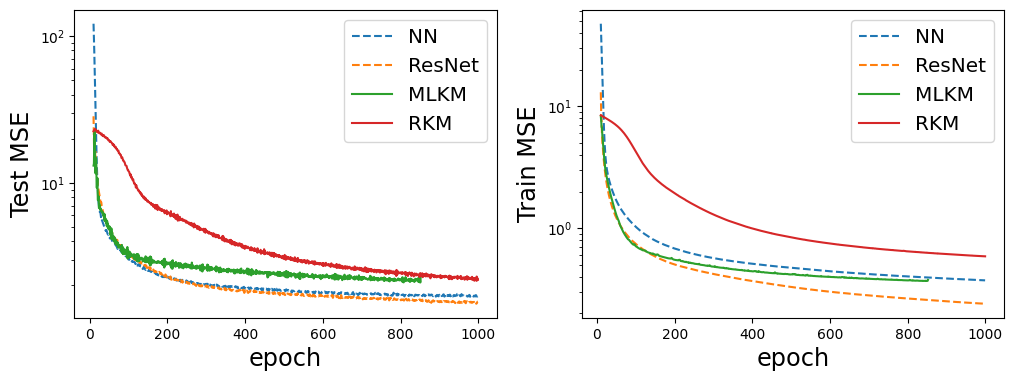

In [75]:
print(dnn_trainloss[-1],res_trainloss[-1],kernelnn_trainloss[-1],reskernel_trainloss[-1])
print(dnn_testloss[-1],res_testloss[-1],kernelnn_testloss[-1],reskernel_testloss[-1])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_choose(ax[0],10,dnn_testloss,linestyle="--")
plot_choose(ax[0],10,res_testloss,linestyle="--")
plot_choose(ax[0],10,kernelnn_testloss)
plot_choose(ax[0],10,reskernel_testloss)
ax[0].legend(["NN","ResNet","MLKM","RKM"],fontsize="x-large")
ax[0].set_xlabel("epoch",fontsize="xx-large")
ax[0].set_ylabel("Test MSE",fontsize="xx-large")
ax[0].set_yscale('log')

plot_choose(ax[1],10,dnn_trainloss,linestyle="--")
plot_choose(ax[1],10,res_trainloss,linestyle="--")
plot_choose(ax[1],10,kernelnn_trainloss)
plot_choose(ax[1],10,reskernel_trainloss)
ax[1].legend(["NN","ResNet","MLKM","RKM"],fontsize="x-large")
ax[1].set_xlabel("epoch",fontsize="xx-large")
ax[1].set_ylabel("Train MSE",fontsize="xx-large")
ax[1].set_yscale('log')
plt.show()

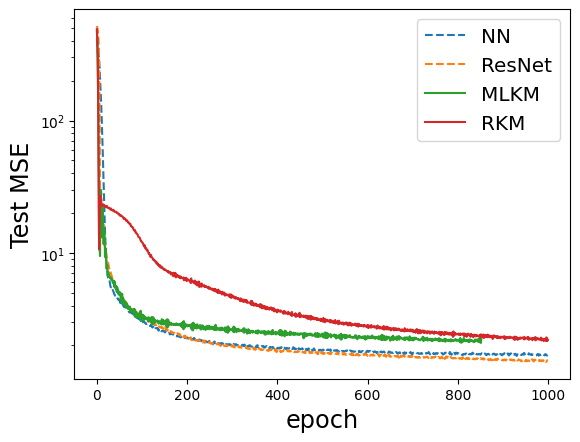

In [76]:
plt.plot(dnn_testloss,linestyle="--")
plt.plot(res_testloss,linestyle="--")
plt.plot(kernelnn_testloss)
plt.plot(reskernel_testloss)
plt.legend(["NN","ResNet","MLKM","RKM"],fontsize="x-large")
plt.xlabel("epoch",fontsize="xx-large")
plt.ylabel("Test MSE",fontsize="xx-large")
plt.yscale('log')
plt.show()